In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Configuration

log_dirs = ["../raw_data/ariec250", "../raw_data/ariec500"]
test_runner_log_filename = "test-runner.log"
enforcer_log_filename = "enforcer.log"
asmeta_server_log_filename = "asmeta-server.log"

test_runner_output_filename = "extracted_test_results.csv"
enforcer_output_filename = "extracted_enforcer_data.csv"
asmeta_output_filename = "extracted_asmeta_data.csv"

ping_file = "../raw_data/ping.txt"

log_pattern = re.compile(
    r"Test #(\d+): expected \[(.*?)\], executed \[(.*?)\] \(check: (True|False)\), time: (.*?) ms"
)
enforcer_delay_pattern = re.compile(r"delay\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
asmeta_server_execution_pattern = re.compile(r"Execution time \(in milliseconds\):\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
ping_log_pattern = re.compile(r"time=([\d.]+)\s*ms")

## Test Runner data analysis

In [3]:
# Data extraction and file saving

records = []

for log_dir in log_dirs:
    experiment_id = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, test_runner_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                test_case_number = int(match.group(1))

                expected_list = [x.strip().strip("'\"") for x in match.group(2).split(",")]
                executed_list = [x.strip().strip("'\"") for x in match.group(3).split(",")]

                # Reordering executed tasks according to the SLEEC definition (so to match the expected ones)
                # Note: the order of executed tasks from the log is random according to the casual callback execution order
                executed_ordered = [x for x in expected_list if x in executed_list]

                expected_str = " AND ".join(expected_list)
                executed_str = " AND ".join(executed_ordered)
                check_val = match.group(4) == "True"

                time_ms = match.group(5)

                records.append({
                    "experiment_id": experiment_id,
                    "test_case_number": test_case_number,
                    "expected_obligation": expected_str,
                    "executed_obligation": executed_str,
                    "check": check_val,
                    "total_enforcement_time": time_ms
                })

df = pd.DataFrame(records)
df["total_enforcement_time"] = pd.to_numeric(df["total_enforcement_time"], errors="coerce")

df.to_csv(test_runner_output_filename, index=False)
df.head()

,experiment_id,test_case_number,expected_obligation,executed_obligation,check,total_enforcement_time
0,ariec250,1,,,True,NaN
1,ariec250,2,encourage,encourage,True,100.0
2,ariec250,3,greetInUserLanguage AND closeDoor AND startTra...,greetInUserLanguage AND closeDoor AND startTra...,True,97.0
3,ariec250,4,wakeUpUser,wakeUpUser,True,90.0
4,ariec250,5,encourage,encourage,True,75.0


## Result consistency check

In [4]:
mask_invalid = ~((df["expected_obligation"] == df["executed_obligation"]) & (df["check"] == True))
invalid_rows = df[mask_invalid]

print(f"Number of rows that do NOT satisfy the consistency requirement: {len(invalid_rows)}")
if not invalid_rows.empty:
    display(invalid_rows)
else:
    print("All rows satisfy: expected_obligation == executed_obligation and check == True")

Number of rows that do NOT satisfy the consistency requirement: 0
All rows satisfy: expected_obligation == executed_obligation and check == True


## Enforcement Subsystem overhead data analysis

In [5]:
# Dataset cleaning

mask = df["total_enforcement_time"] < 4
replaced_count = int(mask.sum())
df.loc[mask, "total_enforcement_time"] = float("nan")

print(f"Replaced {replaced_count} entries with NaN.")

Replaced 37 entries with NaN.


In [6]:
# Analysis of enforcement time

stats = df["total_enforcement_time"].describe()
print("Stats for the total enforcement time:")
print(stats)

print("\nMeasures:")
print(f"Median: {df['total_enforcement_time'].median()}")
print(f"Variance: {df['total_enforcement_time'].var()}")
print(f"Number of NaN (when no obligation needed to be enforced): {df['total_enforcement_time'].count()}")

print("\nStats for experiment ID:")
print(df.groupby("experiment_id")["total_enforcement_time"].describe())

Stats for the total enforcement time:
count    594.000000
mean      76.121212
std        5.718122
min       63.000000
25%       72.000000
50%       75.000000
75%       79.000000
max      104.000000
Name: total_enforcement_time, dtype: float64

Measures:
Median: 75.0
Variance: 32.696918595738126
Number of NaN (when no obligation needed to be enforced): 594

Stats for experiment ID:
               count       mean       std   min   25%   50%    75%    max
experiment_id                                                            
ariec250       198.0  76.707071  5.706444  63.0  73.0  76.5  79.75  100.0
ariec500       396.0  75.828283  5.708604  65.0  72.0  75.0  79.00  104.0


In [7]:
# Focus on highest percentiles
percentiles = [0.90, 0.95, 0.99]
pvals = df["total_enforcement_time"].dropna().quantile(percentiles)
pvals.index = ["90%", "95%", "99%"]

print("Percentile values (ms):")
display(pvals)

Percentile values (ms):


90%    83.70
95%    86.00
99%    93.07
Name: total_enforcement_time, dtype: float64

## Enforcer data analysis

In [8]:
Q1 = df["total_enforcement_time"].dropna().quantile(0.25)
Q2 = df["total_enforcement_time"].dropna().quantile(0.5)
Q3 = df["total_enforcement_time"].dropna().quantile(0.75)

bowley_skewness = (Q3 + Q1 - 2*Q2) / (Q3 - Q1)

print(f"Bowley skewness: {bowley_skewness:.3f}")

Bowley skewness: 0.143


In [9]:
enforcer_iteration_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, enforcer_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = enforcer_delay_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                enforcer_iteration_records.append({
                    "experiment": experiment,
                    "delay_ms": delay_value
                })

df_enforcer_overhead = pd.DataFrame(enforcer_iteration_records)

if not df_enforcer_overhead.empty:
    stats = df_enforcer_overhead.groupby("experiment")["delay_ms"].describe()

    stats["variance"] = df_enforcer_overhead.groupby("experiment")["delay_ms"].var()
    stats["median"] = df_enforcer_overhead.groupby("experiment")["delay_ms"].median()

    # Overall (all data without grouping)
    overall = df_enforcer_overhead["delay_ms"].describe()
    overall["variance"] = df_enforcer_overhead["delay_ms"].var()
    overall["median"] = df_enforcer_overhead["delay_ms"].median()
    stats.loc["all"] = overall

    print("Stats for the enforcer delay:")
    display(stats)

    stats.to_csv(enforcer_output_filename)

Stats for the enforcer delay:


,count,mean,std,min,25%,50%,75%,max,variance,median
experiment,,,,,,,,,,
ariec250,1915.0,43.911593,7.215524,36.25,41.415,43.10,45.19,296.98,52.063791,43.10
ariec500,3910.0,43.451072,4.673706,35.49,41.010,42.78,45.02,200.18,21.843531,42.78
all,5825.0,43.602470,5.640760,35.49,41.140,42.90,45.08,296.98,31.818179,42.90


In [10]:
# Focus on highest percentiles
percentiles = [0.90, 0.95, 0.99]
pvals = df_enforcer_overhead["delay_ms"].dropna().quantile(percentiles)
pvals.index = ["90%", "95%", "99%"]

print("Percentile values (ms):")
display(pvals)

# for label, thresh in pvals.items():
#     subset = df[df["delay_ms"] >= thresh].sort_values(
#         "delay_ms", ascending=False
#     )
#     print(f"\nRows at or above {label} (threshold = {thresh:.2f} ms) — count: {len(subset)}")
#     display(subset)

skew_value = df_enforcer_overhead['delay_ms'].skew()
print(f"Skewness: {skew_value:.3f}")

Q1 = df_enforcer_overhead["delay_ms"].dropna().quantile(0.25)
Q2 = df_enforcer_overhead["delay_ms"].dropna().quantile(0.5)
Q3 = df_enforcer_overhead["delay_ms"].dropna().quantile(0.75)

bowley_skewness = (Q3 + Q1 - 2*Q2) / (Q3 - Q1)

print(f"Bowley skewness: {bowley_skewness:.3f}")

Percentile values (ms):


90%    47.9100
95%    49.9380
99%    55.8228
Name: delay_ms, dtype: float64

Skewness: 20.678
Bowley skewness: 0.107


## ASMETA Server data analysis

In [11]:
asmeta_enforcement_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, asmeta_server_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = asmeta_server_execution_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                asmeta_enforcement_records.append({
                    "experiment": experiment,
                    "delay_ms": delay_value
                })

df_asmeta_overhead = pd.DataFrame(asmeta_enforcement_records)

if not df_asmeta_overhead.empty:
    stats = df_asmeta_overhead.groupby("experiment")["delay_ms"].describe()

    stats["variance"] = df_asmeta_overhead.groupby("experiment")["delay_ms"].var()
    stats["median"] = df_asmeta_overhead.groupby("experiment")["delay_ms"].median()

    # Overall (all data without grouping)
    overall = df_asmeta_overhead["delay_ms"].describe()
    overall["variance"] = df_asmeta_overhead["delay_ms"].var()
    overall["median"] = df_asmeta_overhead["delay_ms"].median()
    stats.loc["all"] = overall

    print("Stats for the asmeta delay:")
    display(stats)

    stats.to_csv(asmeta_output_filename)

Stats for the asmeta delay:


,count,mean,std,min,25%,50%,75%,max,variance,median
experiment,,,,,,,,,,
ariec250,1982.0,1.752775,2.155591,1.0,1.0,1.0,2.0,64.0,4.646572,1.0
ariec500,5825.0,1.648755,1.506360,1.0,1.0,1.0,2.0,64.0,2.269120,1.0
all,7807.0,1.675163,1.695354,1.0,1.0,1.0,2.0,64.0,2.874227,1.0


In [12]:
# Focus on highest percentiles
percentiles = [0.90, 0.95, 0.99]
pvals = df_asmeta_overhead["delay_ms"].dropna().quantile(percentiles)
pvals.index = ["90%", "95%", "99%"]

print("Percentile values (ms):")
display(pvals)

Q1 = df_asmeta_overhead["delay_ms"].dropna().quantile(0.25)
Q2 = df_asmeta_overhead["delay_ms"].dropna().quantile(0.5)
Q3 = df_asmeta_overhead["delay_ms"].dropna().quantile(0.75)

bowley_skewness = (Q3 + Q1 - 2*Q2) / (Q3 - Q1)

print(f"Bowley skewness: {bowley_skewness:.3f}")

Percentile values (ms):


90%    2.0
95%    3.0
99%    8.0
Name: delay_ms, dtype: float64

Bowley skewness: 1.000


## Data reporting

In [13]:
asmeta_mean = df_asmeta_overhead["delay_ms"].mean() if not df_asmeta_overhead.empty else float("nan")
enforcer_mean = df_enforcer_overhead["delay_ms"].mean() if not df_enforcer_overhead.empty else float("nan")
test_runner_mean = df["total_enforcement_time"].mean()

labels = ["Enforcement\nSubsystem", "Enforcer", "ASMETA server"]
values = [test_runner_mean, enforcer_mean, asmeta_mean]


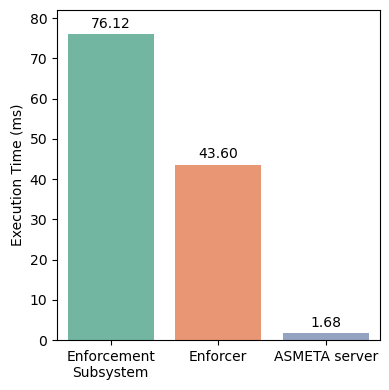

In [14]:
df_barplot = pd.DataFrame({
    "component": labels,
    "time": values
})

plt.figure(figsize=(4, 4))
ax = sns.barplot(data=df_barplot, x="component", y="time", hue="component", palette='Set2')

for i, v in enumerate(values):
    ax.text(i, v + (max(values) * 0.02), f"{v:.2f}", ha='center')

ax.set_ylim(0, 82)

plt.xlabel("")
plt.ylabel("Execution Time (ms)")
plt.tight_layout()

plt.savefig(os.path.join("charts", "components_bar_chart.pdf"), format="pdf", bbox_inches="tight")

plt.show()

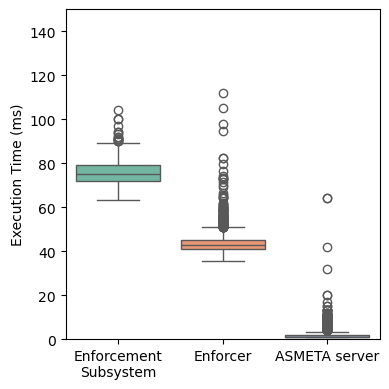

In [15]:
df_box_violin_plot = pd.DataFrame({
    "component": ["Enforcement\nSubsystem"] * len(df["total_enforcement_time"])
                 + ["Enforcer"] * len(df_enforcer_overhead["delay_ms"])
                 + ["ASMETA server"] * len(df_asmeta_overhead["delay_ms"]),
    "time": pd.concat([
        df["total_enforcement_time"],
        df_enforcer_overhead["delay_ms"],
        df_asmeta_overhead["delay_ms"]
    ], ignore_index=True)
})

# Crea il boxplot nello stesso stile del barplot originale
plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_box_violin_plot,
    x="component",
    y="time",
    hue="component",
    palette="Set2"
)

# Imposta limiti, etichette e stile coerente
ax.set_ylim(0, 150)
plt.xlabel("")
plt.ylabel("Execution Time (ms)")
# ax.legend_.remove()  # Rimuove la legenda ridondante

plt.tight_layout()

plt.savefig(os.path.join("charts", "components_box_plot.pdf"), format="pdf", bbox_inches="tight")

plt.show()

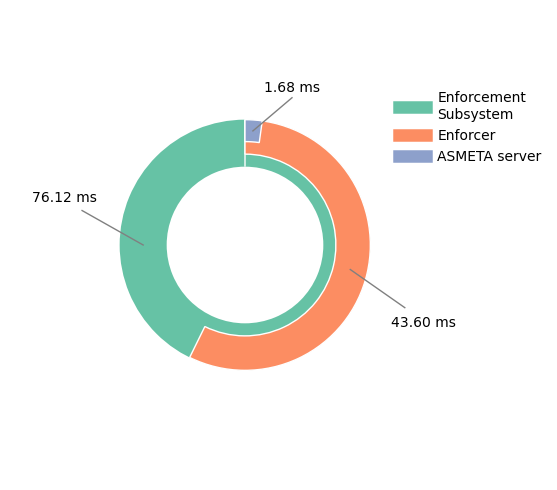

In [16]:
norm_values = [v / test_runner_mean for v in values]

colors = sns.color_palette("Set2", len(values))

fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=dict(aspect="equal"))

base_radius = 0.8
base_width = 0.3

# Overriding label positions
labels_positions = [(-1.15, 0.3), (1.14, -0.5), (0.3, 1.0)]
line_ending_positions = [(-1.04, 0.22), (1.02, -0.4), (0.3, 0.94)]

# From outer to inner ring
for i, (label, value, color) in enumerate(zip(labels, norm_values, colors)):
    radius = base_radius
    ring_width = base_width - i * (0.08)

    wedges, _ = ax.pie(
        [value, 1 - value],
        radius=radius,
        colors=[color, (1,1,1,0)],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=ring_width, edgecolor='none')
    )

    # Wedge border color
    if i > 0:
        wedges[0].set_edgecolor((1,1,1,1))
    else:
        wedges[1].set_edgecolor((1,1,1,1))

    # Line starting point
    if i > 0:
        angle = (90 - value * 360 / 2) * np.pi / 180
    else:
        angle = 180 * np.pi / 180

    x = np.cos(angle) * (radius - ring_width / 2)
    y = np.sin(angle) * (radius - ring_width / 2)
    
    ax.plot([x, line_ending_positions[i][0]], [y, line_ending_positions[i][1]], color="gray", lw=1)

    # Label
    ax.text(
        labels_positions[i][0],
        labels_positions[i][1],
        f"{values[i]:.2f} ms",
        ha="center",
        va="center",
        fontsize=10,
        color="black"
    )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.axis("off")

plt.tight_layout()
# plt.show()

handles = [plt.Line2D([0], [0], color=c, lw=9) for c in colors]
# ax.legend(handles, labels, loc="upper right", fontsize=10)
ax.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.8, 0.75),
    fontsize=10,
    frameon=False
)

plt.savefig(os.path.join("charts", "components_pie_chart.pdf"), format="pdf", bbox_inches="tight")

plt.show()


## Ping analysis

In [17]:
ping_path = os.path.join(ping_file)

if not os.path.exists(ping_path):
    print(f"File not found: {ping_path}")

else:
    ping_records = []
    with open(ping_path, "r", encoding="utf-8") as f:
        for line in f:
            match = ping_log_pattern.search(line)
            if match:
                time_value = float(match.group(1))
                ping_records.append({
                    "time": time_value
                })

    df_ping = pd.DataFrame(ping_records)

    if not df_ping.empty:
        stats = df_ping["time"].describe()

        stats["variance"] = df_ping["time"].var()
        stats["median"] = df_ping["time"].median()

        print("Ping data stats:")
        display(stats)

Ping data stats:


count       65.000000
mean         3.464769
std          1.576651
min          1.770000
25%          2.590000
50%          3.160000
75%          3.680000
max          9.690000
variance     2.485828
median       3.160000
Name: time, dtype: float64

## Deployment comparison
Check results with a different deployment

In [18]:
local_log_path = "../raw_data/local-ariec250/test-runner.log"

if not os.path.exists(local_log_path):
    print(f"File not found: {local_log_path}")
else:
    records = []
    with open(local_log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                time_ms = match.group(5)
                records.append({
                    "total_enforcement_time": time_ms
                })

    df_local = pd.DataFrame(records)

    df_local["total_enforcement_time"] = pd.to_numeric(df_local["total_enforcement_time"], errors="coerce")

    mask_valid = df_local["total_enforcement_time"].notna() & (df_local["total_enforcement_time"] >= 0)
    df_clean = df_local[mask_valid].copy()

    removed_count = len(df_local) - len(df_clean)
    print(f"Total rows: {len(df_local)}. Removed: {removed_count}. Using: {len(df_clean)}")

    if not df_clean.empty:
        stats = df_clean["total_enforcement_time"].describe()
        stats["variance"] = df_clean["total_enforcement_time"].var()
        stats["median"] = df_clean["total_enforcement_time"].median()

        print("\nEnforcement time stats (ms):")
        display(stats)

        percentiles = [0.90, 0.95, 0.99]
        pvals = df_clean["total_enforcement_time"].quantile(percentiles)
        pvals.index = ["90%", "95%", "99%"]
        print("\Percentiles (ms):")
        display(pvals)

        # Bowley skewness se applicabile
        if df_clean["total_enforcement_time"].dropna().shape[0] >= 3:
            Q1 = df_clean["total_enforcement_time"].quantile(0.25)
            Q2 = df_clean["total_enforcement_time"].quantile(0.5)
            Q3 = df_clean["total_enforcement_time"].quantile(0.75)
            bowley_skewness = (Q3 + Q1 - 2 * Q2) / (Q3 - Q1) if (Q3 - Q1) != 0 else float("nan")
            print(f"\nBowley skewness: {bowley_skewness:.3f}")
    else:
        print("No data")

Total rows: 256. Removed: 53. Using: 203

Enforcement time stats (ms):


count       203.000000
mean        113.463054
std          25.945914
min          80.000000
25%         102.000000
50%         109.000000
75%         117.000000
max         364.000000
variance    673.190460
median      109.000000
Name: total_enforcement_time, dtype: float64

\Percentiles (ms):


90%    127.00
95%    140.50
99%    207.76
Name: total_enforcement_time, dtype: float64


Bowley skewness: 0.067
